# 공유오피스 데이터 기반 비즈니스 지표 분석 프로젝트

본 프로젝트는 공유오피스 서비스의 3일 체험 신청, 방문 및 출입 기록, 결제 여부, 지점별 면적 등 다양한 데이터를 바탕으로 비즈니스 지표의 추이를 예측하고, 서비스 개선 방향성을 제시하는 것을 목표로 합니다.

---

## 목차
1. 프로젝트 개요
2. 데이터셋 소개
3. 데이터 불러오기 및 구조 확인
4. EDA(탐색적 데이터 분석)
5. 결론 및 비즈니스 인사이트

---

## 1. 프로젝트 개요
- 공유오피스 서비스의 현재 상태를 분석하고, 머신러닝 기법을 활용해 향후 개선점을 제안합니다.
- 예시: 무료 유저의 유료 전환율 예측, 오피스 이용량 예측, 방문 패턴 분석 등

## 2. 데이터셋 소개
- 2021.05.01 ~ 2023.12.31 (2년 8개월치)
- 주요 테이블:
    - **trial_register**: 3일체험 신청
    - **trial_visit_info**: 3일체험 신청자 일자별 방문기록
    - **trial_access_log**: 3일체험 신청자 출입기록
    - **trial_payment**: 3일체험 신청자 결제 여부
    - **site_area**: 지점별 면적

---

## 3. 데이터 불러오기 및 구조 확인

각 테이블의 데이터를 pandas로 불러오고, 기본적인 구조(컬럼, row 수, 샘플 데이터)를 확인합니다.

In [9]:
# 라이브러리 import 및 데이터 불러오기
import pandas as pd

# 파일 경로
register_path = 'trial_register.csv'
visit_info_path = 'trial_visit_info.csv'
access_log_path = 'trial_access_log.csv'
payment_path = 'trial_payment.csv'
site_area_path = 'site_area.csv'

# 데이터 불러오기
df_register = pd.read_csv(register_path)
df_visit_info = pd.read_csv(visit_info_path)
df_access_log = pd.read_csv(access_log_path)
df_payment = pd.read_csv(payment_path)
df_site_area = pd.read_csv(site_area_path)

# 데이터프레임 리스트로 관리 (파일명과 동일하게)
dfs = {
    'trial_register': df_register,
    'trial_visit_info': df_visit_info,
    'trial_access_log': df_access_log,
    'trial_payment': df_payment,
    'site_area': df_site_area
}

In [10]:
# 각 데이터프레임의 기본 정보 확인
for name, df in dfs.items():
    print(f'===== {name} =====')
    print(f'Shape: {df.shape}')
    print(f'Columns: {df.columns.tolist()}')
    display(df.head(3))
    print('\n')

===== trial_register =====
Shape: (9659, 2)
Columns: ['trial_date', 'user_uuid']


,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3




===== trial_visit_info =====
Shape: (11477, 7)
Columns: ['site_id', 'date', 'stay_time', 'stay_time_second', 'first_enter_time', 'last_leave_time', 'user_uuid']


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73




===== trial_access_log =====
Shape: (63708, 5)
Columns: ['id', 'checkin', 'cdate', 'site_id', 'user_uuid']


,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 07:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-06 15:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 14:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89




===== trial_payment =====
Shape: (9659, 2)
Columns: ['is_payment', 'user_uuid']


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3




===== site_area =====
Shape: (9, 2)
Columns: ['site_id', 'area_pyeong']


,site_id,area_pyeong
0,1,50
1,2,100
2,3,150


---

## 4. EDA(탐색적 데이터 분석)

각 테이블별 주요 통계, 결측치, 분포, 상관관계 등을 시각화 및 분석합니다.

- 4.1 3일체험 신청 데이터 분석
- 4.2 방문 및 출입기록 분석
- 4.3 결제 전환율 분석
- 4.4 지점별 면적 및 이용 패턴 분석


### 4.1 기초 통계 및 결측치, 주요 컬럼 중복/유일값 분석

- 각 테이블의 행/열 수, 결측치 비율, 주요 컬럼(user_uuid, site_id)의 중복 및 유일값 개수를 확인합니다.

In [11]:
# 각 테이블의 행/열 수, 결측치 비율, 주요 컬럼(user_uuid, site_id) 중복 및 유일값 개수 확인
for name, df in dfs.items():
    print(f'===== {name} =====')
    print(f'Shape: {df.shape}')
    print('Null 비율:')
    print((df.isnull().mean() * 100).round(2))
    print('\n')
    
    for col in ['user_uuid', 'site_id']:
        if col in df.columns:
            n_unique = df[col].nunique()
            n_total = len(df)
            n_dup = n_total - df[col].nunique()
            print(f'컬럼: {col}')
            print(f' - 유일값 개수: {n_unique}')
            print(f' - 전체 대비 유일값 비율: {n_unique/n_total:.2%}')
            print(f' - 중복값 개수: {n_dup}')
    print('\n')

===== trial_register =====
Shape: (9659, 2)
Null 비율:
trial_date    0.0
user_uuid     0.0
dtype: float64


컬럼: user_uuid
 - 유일값 개수: 9624
 - 전체 대비 유일값 비율: 99.64%
 - 중복값 개수: 35


===== trial_visit_info =====
Shape: (11477, 7)
Null 비율:
site_id             0.00
date                0.00
stay_time           0.00
stay_time_second    0.00
first_enter_time    4.84
last_leave_time     4.84
user_uuid           0.00
dtype: float64


컬럼: user_uuid
 - 유일값 개수: 6534
 - 전체 대비 유일값 비율: 56.93%
 - 중복값 개수: 4943
컬럼: site_id
 - 유일값 개수: 9
 - 전체 대비 유일값 비율: 0.08%
 - 중복값 개수: 11468


===== trial_access_log =====
Shape: (63708, 5)
Null 비율:
id           0.0
checkin      0.0
cdate        0.0
site_id      0.0
user_uuid    0.0
dtype: float64


컬럼: user_uuid
 - 유일값 개수: 6026
 - 전체 대비 유일값 비율: 9.46%
 - 중복값 개수: 57682
컬럼: site_id
 - 유일값 개수: 9
 - 전체 대비 유일값 비율: 0.01%
 - 중복값 개수: 63699


===== trial_payment =====
Shape: (9659, 2)
Null 비율:
is_payment    0.0
user_uuid     0.0
dtype: float64


컬럼: user_uuid
 - 유일값 개수: 9624
 - 전체 대비 

## 1. 기초 통계 및 결측치 확인

### 1.1 `trial_register.csv`
- 총 9,659행, 2개 컬럼
- 결측치 없음
- `user_uuid` 기준 유일값은 9,624개로, 중복이 35건 존재함  
  → 동일 유저의 중복 신청 가능성 있음

---

### 1.2 `trial_visit_info.csv`
- 총 11,477행, 7개 컬럼
- `first_enter_time`, `last_leave_time` 컬럼에 각각 4.84%의 결측치 존재  
  → 출입기록은 있으나 방문 정보가 비정상적으로 기록되지 않았을 가능성 있음
- `user_uuid` 유일값은 6,534개 (중복 많음)
- `site_id`는 총 9개 지점

---

### 1.3 `trial_access_log.csv`
- 총 63,708행, 5개 컬럼
- 결측치 없음
- `user_uuid` 유일값 6,026명 → 로그 단위로 다수의 중복 존재
- `site_id`도 9개 지점

---

### 1.4 `trial_payment.csv`
- 총 9,659행, 2개 컬럼
- 결측치 없음
- `user_uuid` 기준 유일값은 9,624개  
  → `trial_register`와 거의 동일한 유저 구성 (중복 35건 동일)

---

### 1.5 `site_area.csv`
- 총 9행, 2개 컬럼
- 결측치 없음
- `site_id` 9개 모두 유일값

---

✅ **요약**: 전체적으로 결측치는 매우 적고 관리 상태 양호함. 다만 `trial_visit_info`의 입실/퇴실 시간 결측이 약간 존재하며, 중복된 유저 신청(35명)은 처리 기준을 별도로 고려해야 함.


### 4.2 유저 행동 분석

- trial_register(체험 신청) 기준으로 trial_visit_info(방문 기록)와 조인하여 유저별 행동 패턴을 분석합니다.
    - 체험 신청 → 첫 방문까지 소요 일수(first_visit_delay) 분포
    - 유저별 방문 일수(visit_days) 분포
    - 유저별 총 체류 시간(total_stay_time) 분포
    - 유저별 방문 지점 수(unique_sites) 분포
    - 유저별 최초 방문 요일/시간대 시각화(히트맵)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 체험 신청일과 방문기록 조인 (user_uuid 기준)
register = dfs['trial_register'].copy()
visit = dfs['trial_visit_info'].copy()

In [19]:
visit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11477 entries, 0 to 11476
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   site_id           11477 non-null  int64 
 1   date              11477 non-null  object
 2   stay_time         11477 non-null  object
 3   stay_time_second  11477 non-null  int64 
 4   first_enter_time  10922 non-null  object
 5   last_leave_time   10922 non-null  object
 6   user_uuid         11477 non-null  object
dtypes: int64(2), object(5)
memory usage: 627.8+ KB


In [21]:

# 날짜형 변환
register['trial_date'] = pd.to_datetime(register['trial_date'])
visit['date'] = pd.to_datetime(visit['date'])

# 유저별 첫 방문일
first_visit = visit.groupby('user_uuid')['date'].min().reset_index().rename(columns={'date': 'first_visit_date'})

# 신청일과 첫 방문일 join
register = register.merge(first_visit, on='user_uuid', how='left')
register['first_visit_delay'] = (register['first_visit_date'] - register['trial_date']).dt.days

# 유저별 방문 일수
visit_days = visit.groupby('user_uuid')['date'].nunique().reset_index().rename(columns={'date': 'visit_days'})

# 유저별 총 체류 시간(분)
visit['stay_time'] = pd.to_numeric(visit['stay_time'], errors='coerce')
total_stay = visit.groupby('user_uuid')['stay_time'].sum().reset_index().rename(columns={'stay_time': 'total_stay_time'})

# 유저별 방문 지점 수
unique_sites = visit.groupby('user_uuid')['site_id'].nunique().reset_index().rename(columns={'site_id': 'unique_sites'})

# 유저별 최초 방문 요일/시간대
first_visit_info = visit.sort_values(['user_uuid', 'date']).drop_duplicates('user_uuid', keep='first')
first_visit_info['weekday'] = first_visit_info['date'].dt.dayofweek  # 0=월~6=일
first_visit_info['hour'] = pd.to_datetime(first_visit_info['first_enter_time'], errors='coerce').dt.hour


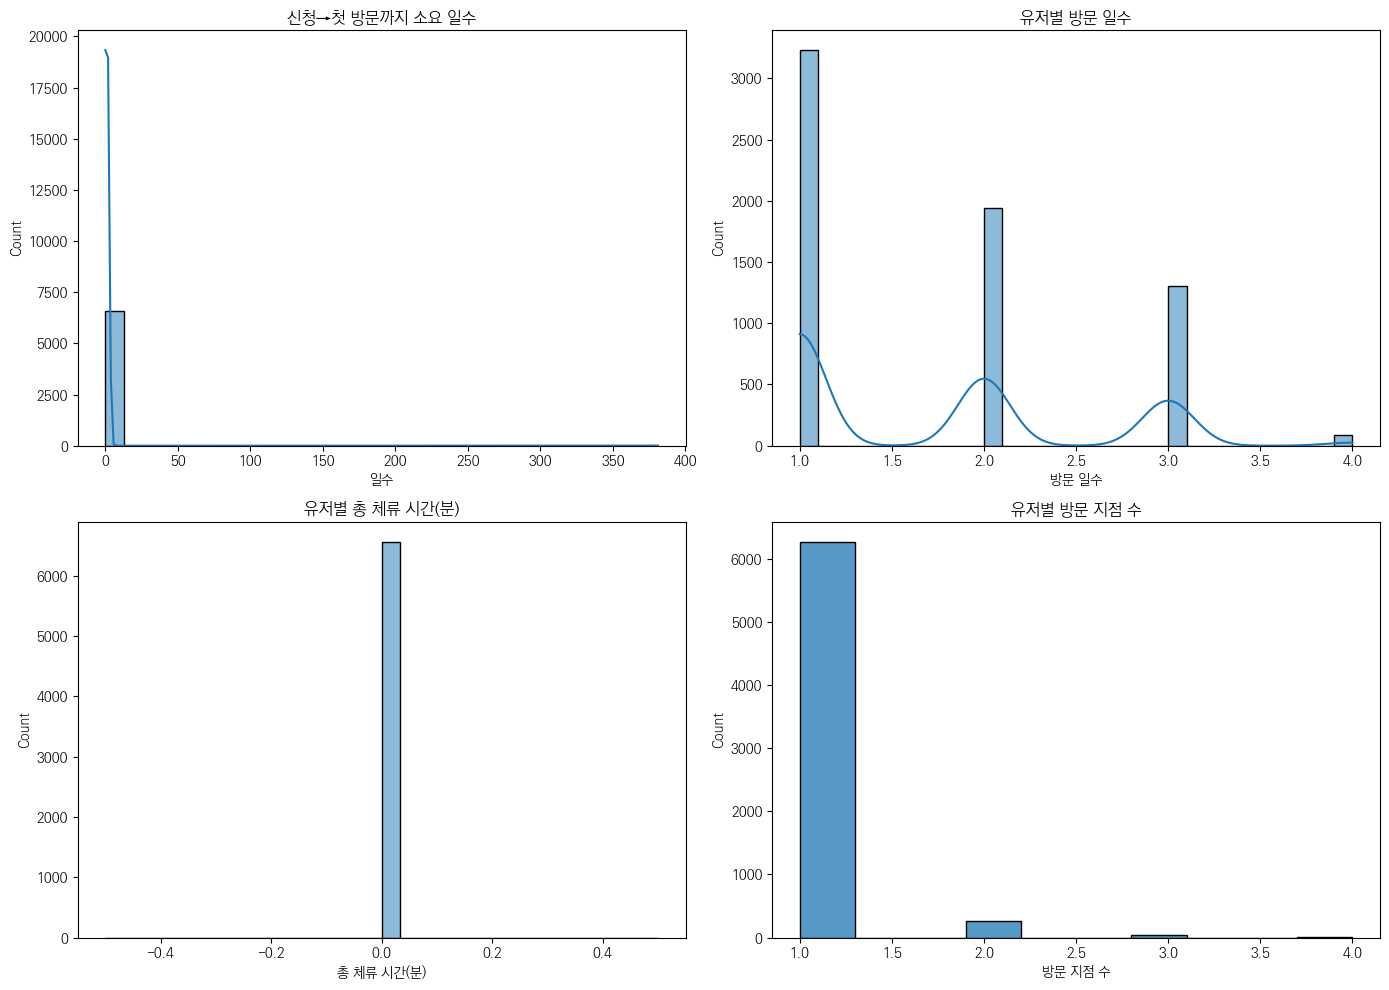

In [22]:
# 유저별 feature merge
user_features = register[['user_uuid', 'first_visit_delay']].merge(
    visit_days, on='user_uuid', how='left'
).merge(
    total_stay, on='user_uuid', how='left'
).merge(
    unique_sites, on='user_uuid', how='left'
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 체험 신청→첫 방문까지 소요 일수
sns.histplot(user_features['first_visit_delay'].dropna(), bins=30, ax=axes[0,0], kde=True)
axes[0,0].set_title('신청→첫 방문까지 소요 일수')
axes[0,0].set_xlabel('일수')

# 2. 유저별 방문 일수
sns.histplot(user_features['visit_days'].dropna(), bins=30, ax=axes[0,1], kde=True)
axes[0,1].set_title('유저별 방문 일수')
axes[0,1].set_xlabel('방문 일수')

# 3. 유저별 총 체류 시간(분)
sns.histplot(user_features['total_stay_time'].dropna(), bins=30, ax=axes[1,0], kde=True)
axes[1,0].set_title('유저별 총 체류 시간(분)')
axes[1,0].set_xlabel('총 체류 시간(분)')

# 4. 유저별 방문 지점 수
sns.histplot(user_features['unique_sites'].dropna(), bins=10, ax=axes[1,1], kde=False)
axes[1,1].set_title('유저별 방문 지점 수')
axes[1,1].set_xlabel('방문 지점 수')

plt.tight_layout()
plt.show()

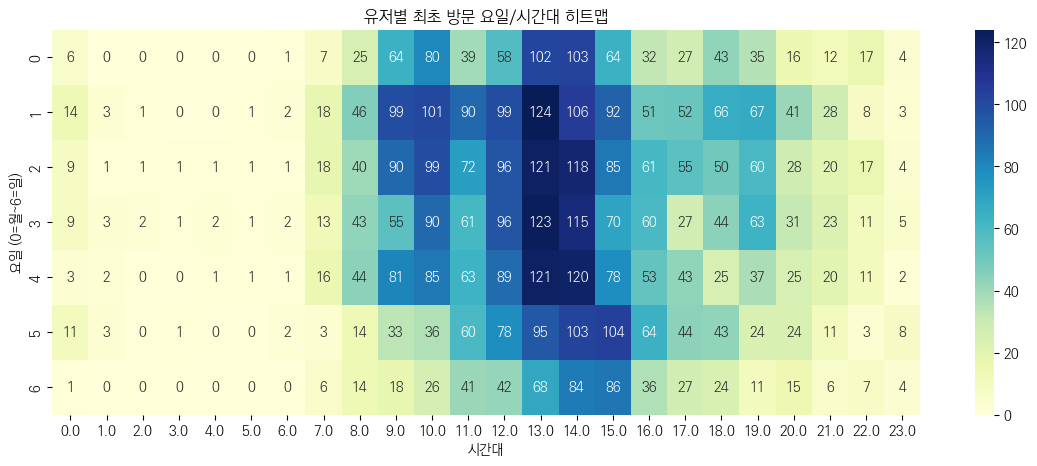

In [23]:
# 유저별 최초 방문 요일/시간대 히트맵
pivot = first_visit_info.pivot_table(index='weekday', columns='hour', values='user_uuid', aggfunc='count', fill_value=0)

plt.figure(figsize=(14,5))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='d')
plt.title('유저별 최초 방문 요일/시간대 히트맵')
plt.xlabel('시간대')
plt.ylabel('요일 (0=월~6=일)')
plt.show()

#### [추가 EDA] 방문 패턴 심화 분석

2. 결제 전환 유저 vs 미전환 유저의 최초 방문 요일/시간대 비교
3. 지점별 방문 요일/시간대 히트맵
4. 체험 신청 후 3일 이내/이후 방문의 요일/시간대 분포 비교


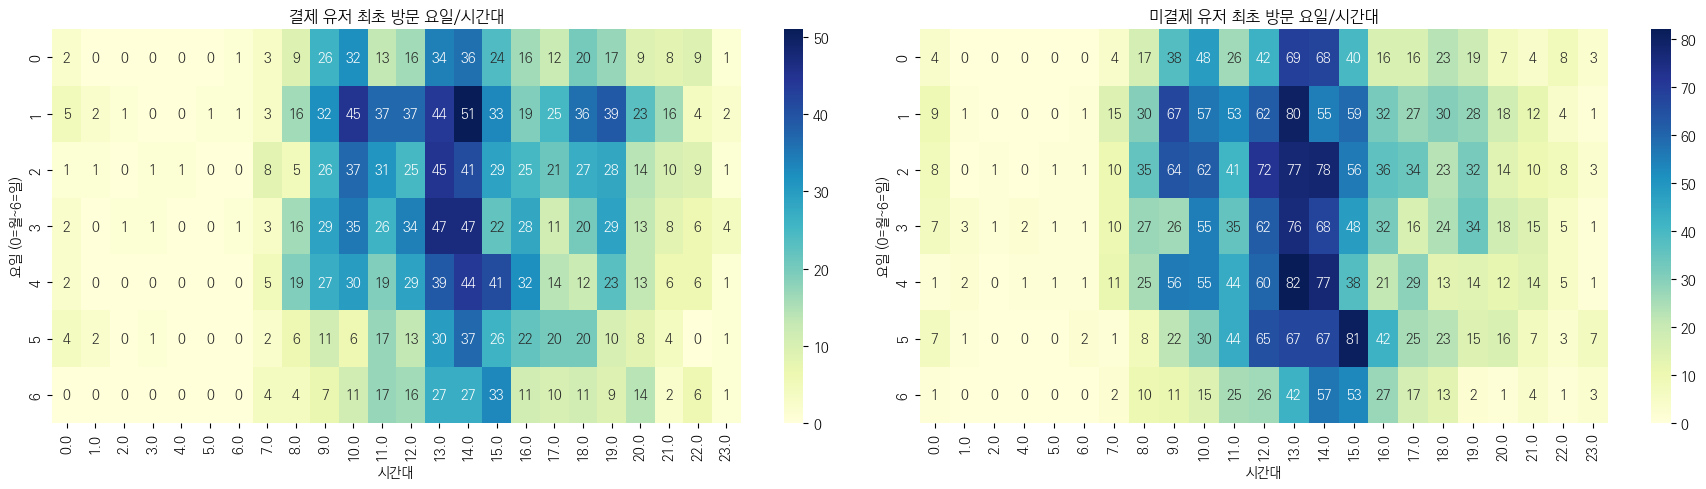

In [27]:
# 2. 결제 전환 유저 vs 미전환 유저의 최초 방문 요일/시간대 비교
payment = dfs['trial_payment'].copy()
payment['is_payment'] = payment['is_payment'].astype(str)

# 결제 여부 join
tmp = first_visit_info.merge(payment[['user_uuid', 'is_payment']], on='user_uuid', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18,5))
for i, paid in enumerate(['1', '0']):
    subset = tmp[tmp['is_payment'] == paid]
    pivot = subset.pivot_table(index='weekday', columns='hour', values='user_uuid', aggfunc='count', fill_value=0)
    sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(f"{'결제' if paid=='1' else '미결제'} 유저 최초 방문 요일/시간대")
    axes[i].set_xlabel('시간대')
    axes[i].set_ylabel('요일 (0=월~6=일)')
plt.tight_layout()
plt.show()

In [ ]:
dfs['trial_visit_info']['site_id'].unique()

# 사이트 영역별 방문자 수

"""
1,50
2,100
3,150
4,100
5,150
6,150
17,50
47,50
49,50
"""

array([ 1,  3,  6, 17,  4,  2, 49, 47,  5], dtype=int64)

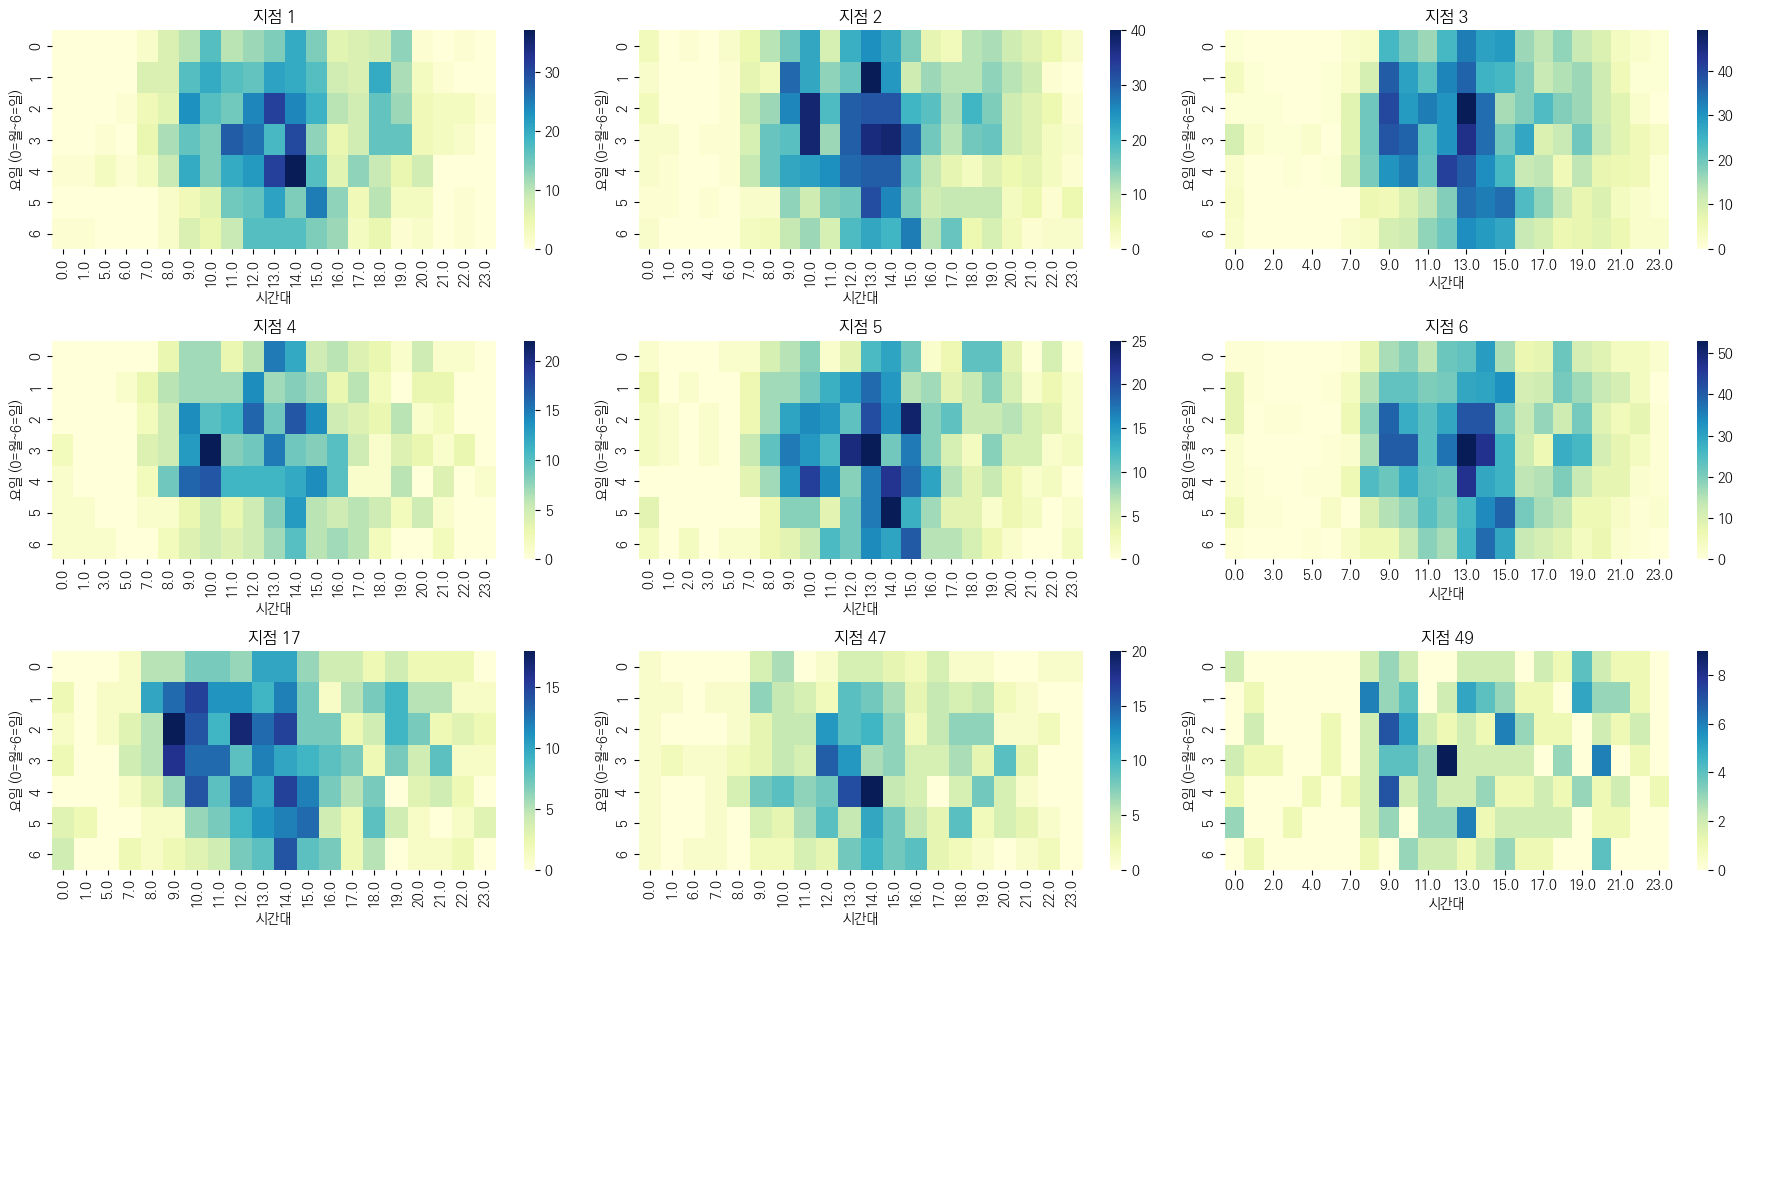

In [ ]:
# 3. 지점별 방문 요일/시간대 히트맵
visit = dfs['trial_visit_info'].copy()
visit['date'] = pd.to_datetime(visit['date'])
visit['weekday'] = visit['date'].dt.dayofweek
visit['hour'] = pd.to_datetime(visit['first_enter_time'], errors='coerce').dt.hour

site_ids = visit['site_id'].unique()
fig, axes = plt.subplots(len(site_ids)//3+1, 3, figsize=(18, 3*len(site_ids)//3+3))
axes = axes.flatten()
for i, site in enumerate(sorted(site_ids)):
    subset = visit[visit['site_id'] == site]
    pivot = subset.pivot_table(index='weekday', columns='hour', values='user_uuid', aggfunc='count', fill_value=0)
    sns.heatmap(pivot, cmap='YlGnBu', annot=False, ax=axes[i])
    axes[i].set_title(f'지점 {site}')
    axes[i].set_xlabel('시간대')
    axes[i].set_ylabel('요일 (0=월~6=일)')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

""" 저이용 지점(지점 49)는 무슨 문제가 있기에 저런 분포를 띄는가?"""

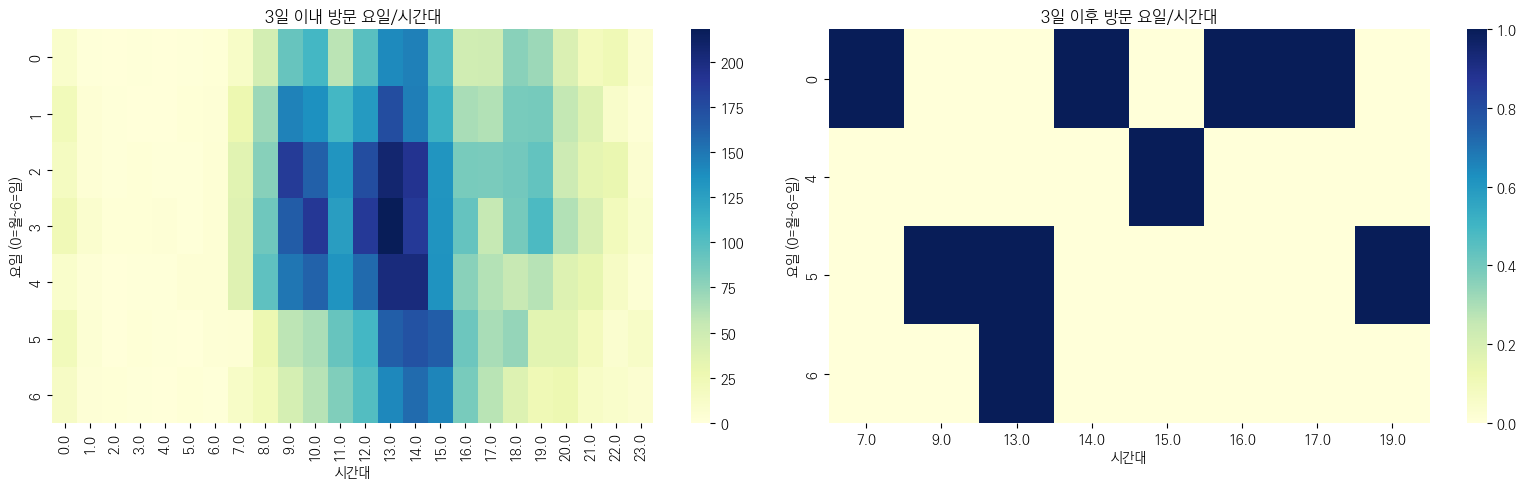

In [32]:
# 4. 체험 신청 후 3일 이내/이후 방문의 요일/시간대 분포 비교
register = dfs['trial_register'].copy()
register['trial_date'] = pd.to_datetime(register['trial_date'])
visit = dfs['trial_visit_info'].copy()
visit['date'] = pd.to_datetime(visit['date'])
visit = visit.merge(register[['user_uuid', 'trial_date']], on='user_uuid', how='left')
visit['days_from_trial'] = (visit['date'] - visit['trial_date']).dt.days
visit['period'] = np.where(visit['days_from_trial'] <= 3, '3일 이내', '3일 이후')
visit['weekday'] = visit['date'].dt.dayofweek
visit['hour'] = pd.to_datetime(visit['first_enter_time'], errors='coerce').dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16,5))
for i, period in enumerate(['3일 이내', '3일 이후']):
    subset = visit[visit['period'] == period]
    pivot = subset.pivot_table(index='weekday', columns='hour', values='user_uuid', aggfunc='count', fill_value=0)
    sns.heatmap(pivot, cmap='YlGnBu', annot=False, ax=axes[i])
    axes[i].set_title(f'{period} 방문 요일/시간대')
    axes[i].set_xlabel('시간대')
    axes[i].set_ylabel('요일 (0=월~6=일)')
plt.tight_layout()
plt.show()

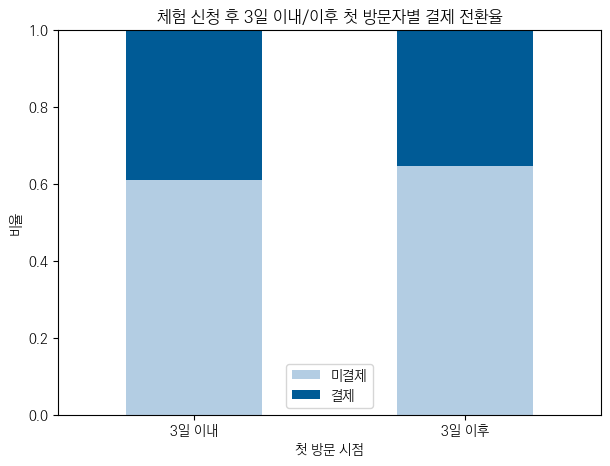

In [33]:
# 체험 신청 후 3일 이내/이후 첫 방문자 그룹별 결제 전환율 분포
register = dfs['trial_register'].copy()
register['trial_date'] = pd.to_datetime(register['trial_date'])
visit = dfs['trial_visit_info'].copy()
visit['date'] = pd.to_datetime(visit['date'])
payment = dfs['trial_payment'].copy()

# 유저별 첫 방문일
first_visit = visit.groupby('user_uuid')['date'].min().reset_index().rename(columns={'date': 'first_visit_date'})
register = register.merge(first_visit, on='user_uuid', how='left')
register['first_visit_delay'] = (register['first_visit_date'] - register['trial_date']).dt.days
register['visit_period'] = np.where(register['first_visit_delay'] <= 3, '3일 이내', '3일 이후')

# 결제 여부 join
register = register.merge(payment[['user_uuid', 'is_payment']], on='user_uuid', how='left')

# 그룹별 결제 전환율
pivot = register.groupby('visit_period')['is_payment'].value_counts(normalize=True).unstack().fillna(0)

# 히스토그램 시각화
fig, ax = plt.subplots(figsize=(7,5))
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#b3cde3', '#005b96'])
plt.title('체험 신청 후 3일 이내/이후 첫 방문자별 결제 전환율')
plt.ylabel('비율')
plt.xlabel('첫 방문 시점')
plt.xticks(rotation=0)
plt.legend(['미결제', '결제'])
plt.ylim(0,1)
plt.show()

### 4.3 지점별 분석

- 지점별 총 방문자 수, 평균 체류 시간
- 지점별 결제율
- 지점 면적 대비 방문 밀도(체류시간/면적)
- 지점별 시간대 이용 히트맵(혼잡 시간대 파악)


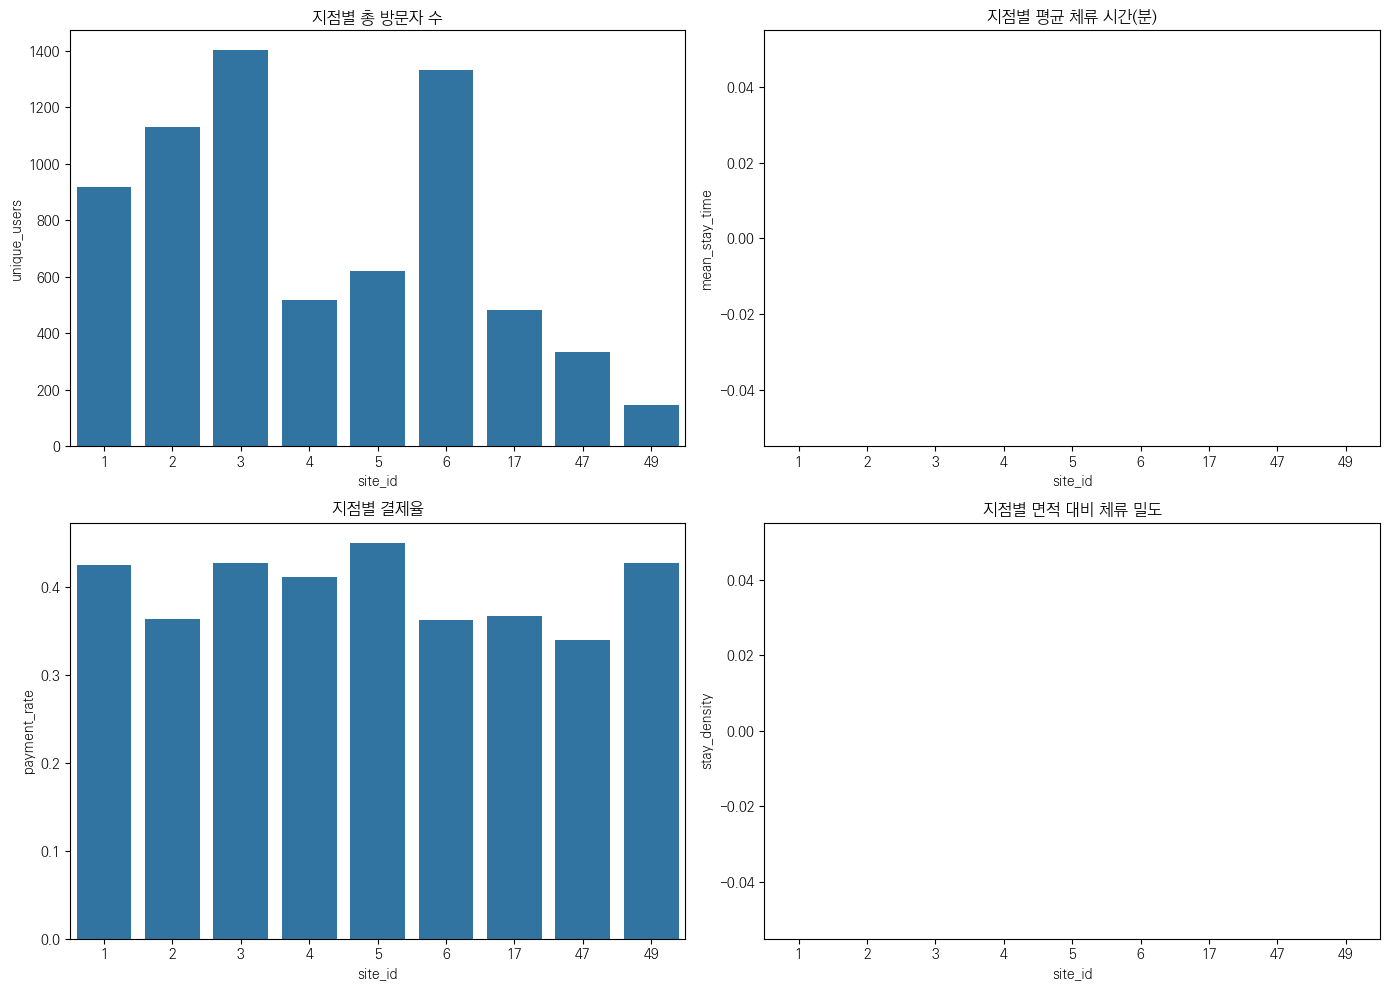

,site_id,unique_users,mean_stay_time,paid_users,area_pyeong,total_stay_time,payment_rate,stay_density
0,1,918,NaN,390,50,0.0,0.424837,0.0
1,2,1131,NaN,412,100,0.0,0.364279,0.0
2,3,1402,NaN,600,150,0.0,0.427960,0.0
3,4,517,NaN,213,100,0.0,0.411992,0.0
4,5,619,NaN,279,150,0.0,0.450727,0.0
5,6,1331,NaN,482,150,0.0,0.362134,0.0
6,17,482,NaN,177,50,0.0,0.367220,0.0
7,47,332,NaN,113,50,0.0,0.340361,0.0
8,49,145,NaN,62,50,0.0,0.427586,0.0


In [42]:
# 지점별 총 방문자 수, 평균 체류 시간, 결제율, 면적 대비 밀도
visit = dfs['trial_visit_info'].copy()
visit['stay_time'] = pd.to_numeric(visit['stay_time'], errors='coerce')
site_area = dfs['site_area'].copy()
payment = dfs['trial_payment'].copy()

# 지점별 총 방문자 수(유니크 유저)
site_user = visit.groupby('site_id')['user_uuid'].nunique().reset_index().rename(columns={'user_uuid': 'unique_users'})
# 지점별 평균 체류 시간
site_stay = visit.groupby('site_id')['stay_time'].mean().reset_index().rename(columns={'stay_time': 'mean_stay_time'})

# 결제 유저의 방문 지점 집계
df_paid = payment[payment['is_payment'] == 1].merge(visit[['user_uuid', 'site_id']], on='user_uuid')
site_paid = df_paid.groupby('site_id')['user_uuid'].nunique().reset_index().rename(columns={'user_uuid': 'paid_users'})

# 지점별 총 체류 시간(전체 방문 기준)
total_stay = visit.groupby('site_id')['stay_time'].sum().reset_index().rename(columns={'stay_time': 'total_stay_time'})

# 결제율 = 결제유저/전체유저
g_site = site_user.merge(site_stay, on='site_id', how='left').merge(site_paid, on='site_id', how='left').merge(site_area, on='site_id', how='left').merge(total_stay, on='site_id', how='left')
g_site['paid_users'] = g_site['paid_users'].fillna(0)
g_site['payment_rate'] = g_site['paid_users'] / g_site['unique_users']

# 면적 대비 방문 밀도 (총 체류시간/면적)
g_site['stay_density'] = g_site['total_stay_time'] / g_site['area_pyeong']

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14,10))
sns.barplot(data=g_site, x='site_id', y='unique_users', ax=axes[0,0])
axes[0,0].set_title('지점별 총 방문자 수')
sns.barplot(data=g_site, x='site_id', y='mean_stay_time', ax=axes[0,1])
axes[0,1].set_title('지점별 평균 체류 시간(분)')
sns.barplot(data=g_site, x='site_id', y='payment_rate', ax=axes[1,0])
axes[1,0].set_title('지점별 결제율')
sns.barplot(data=g_site, x='site_id', y='stay_density', ax=axes[1,1])
axes[1,1].set_title('지점별 면적 대비 체류 밀도')
plt.tight_layout()
plt.show()
g_site